# introduction to quantum audio
Article : [Quantum Representations of Sound: from
mechanical waves to quantum circuits](https://arxiv.org/pdf/2301.01595)


#  Multichannel Quantum State Modulation: MQSM

$$ |A_{MQSM}\rangle = \frac{1}{\sqrt{NC}}\sum_{i=0}^{N-1}\sum_{j=0}^{C-1} |c_j\rangle\otimes|a_{i,j}\rangle\otimes|t_{i,j}\rangle$$

The QRMA (Quantum Representation of Multi-Channel Audio), extends the logic of a state-oriented representation for quantum audio. In our naming system, it is called Multichannel Quantum State Modulation (MQSM). It furthers the QSM implementation logic by introducing a new quantum register in the circuit: the channel register. With this new register, we can address, for example, left ($|0\rangle$) and right ($|1\rangle$) channels of a stereo audio 


The time register use $n$ qubits, the amplitudes register use $q$ qubits, and $1$ qubit for the channel. 

## Preparation

Value-Setting Operation: For each time state,
- Step 1: Have a binary form of the time state’s label stored in a classical variable.
- Step 2: Have the binary form of the quantized audio sample at the same index
- Step 3: If a bit in a given position of the time variable is zero, apply an X gate at the
respective qubit. Verify all bits.
- Step 4: If a bit in a given position of the audio sample is 1, apply a multi-controlled
CNOT gate. Verify all bits.
- Step 5: Repeat the third instruction to reset the control condition.

In [1]:
# importation of the modules
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import MCXGate
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
# Functions 
def getFullScaleMeasured(statistics, Nqubits):
    """
    fill the string measured with the null values measured
    Input : 
        - statistics(dict)
        - Nqubits(int)
    Output:
        - full_statistics(dict): statistics with the null values
    """
    full_statistics = {}
    for i in range(2**Nqubits):
        # Converts the integer i to binary and adds leading zeros (padding)
        bitstring = format(i, f'0{Nqubits}b')
        
        # If the flag is set, we take its value; otherwise, we set it to 0
        full_statistics[bitstring] = statistics.get(bitstring, 0)
    return full_statistics

# generation of the binary list depending of the number of qubits
def generate_binary_list_from_nqubits(n_qubits):
    """
    Generates binary strings in ascending numerical order.
    Example for 2 qubits: [‘00’, ‘01’, ‘10’, ‘11’]
    Input: 
        - n_qubits(Int) : number of qubits
    Output:
        - list of 2**n_qubits binary ascendant
    """
    return [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]

def quantize2normalize(quantizeSignal: np.array, Resolution: int):
    """
    Convert the quantized signal(amplitudes 0 and 2**Resolution) 
                to normalized signal(amplitudes between -1 and 1)
    """
    normalizeSignal =  2*(quantizeSignal/(2**Resolution-1))-1
    return normalizeSignal

def normalize2quantize(signal: np.array, Resolution: int):
    """
    Convert the normalized signal(amplitudes between -1 and 1)
                to quantized signal(amplitudes between 0 and 2**Resolution).
    """
    quantizeSignal = np.round((signal+1)/2*(2**Resolution-1))
    return quantizeSignal


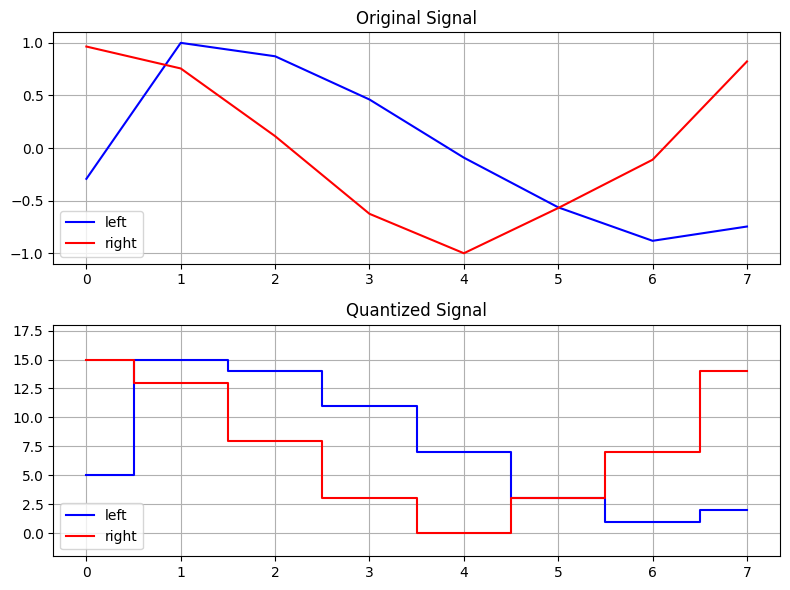

In [3]:
# Creation of an audio signal, in this example, we consider that the audio is stereo, so we have 2 channels (Left/Right)

# Resolution
AmpQubits = 4   # better resolution with an high number of amplitude qubits 
TimeQubits = 3
ChannelQubits = 1

# time vector
temp = np.arange(0,2**TimeQubits, 1)/2**TimeQubits

# Creation of a signal 
signal1 = np.sin(2*np.pi*temp)+0.2*np.random.randn(2**TimeQubits) # sinus wave + random data
signal1/=np.max(np.abs(signal1)) # normalization

signal2 = np.cos(2*np.pi*temp)+0.2*np.random.randn(2**TimeQubits) # sinus wave + random data
signal2/=np.max(np.abs(signal2)) # normalization

# Quantization of the signal 
quantizeSignal1 = normalize2quantize(signal1, AmpQubits)
quantizeSignal2 = normalize2quantize(signal2, AmpQubits)


# Plot the signal and the quantized signal 
fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(signal1, color='blue', label="left")
axs[0].plot(signal2, color='red', label="right")
axs[0].set_title("Original Signal")
axs[0].set_ylim([-1.1, 1.1])
axs[0].grid(True)
axs[0].legend()

axs[1].plot(quantizeSignal1, color='blue', drawstyle='steps-mid', label="left")
axs[1].plot(quantizeSignal2, color='red', drawstyle='steps-mid', label="right")
axs[1].set_title("Quantized Signal")
axs[1].grid(True)
axs[1].legend()
axs[1].set_ylim([-2, 2**AmpQubits+2])
plt.tight_layout()
plt.show()

In [4]:
# convert samples to binary value
signal_binary1 = [f"{x:0{AmpQubits}b}" for x in quantizeSignal1.astype(int)]
signal_binary2 = [f"{x:0{AmpQubits}b}" for x in quantizeSignal2.astype(int)]


print(f"Binary representation of the signal 1(Left) : {signal_binary1}")
print(f"Binary representation of the signal 2(Right): {signal_binary2}")

# time binary values 
TimeBin = generate_binary_list_from_nqubits(TimeQubits)
print(f"Binary representation of the time : {TimeBin}")

Binary representation of the signal 1(Left) : ['0101', '1111', '1110', '1011', '0111', '0011', '0001', '0010']
Binary representation of the signal 2(Right): ['1111', '1101', '1000', '0011', '0000', '0011', '0111', '1110']
Binary representation of the time : ['000', '001', '010', '011', '100', '101', '110', '111']


### Preparation

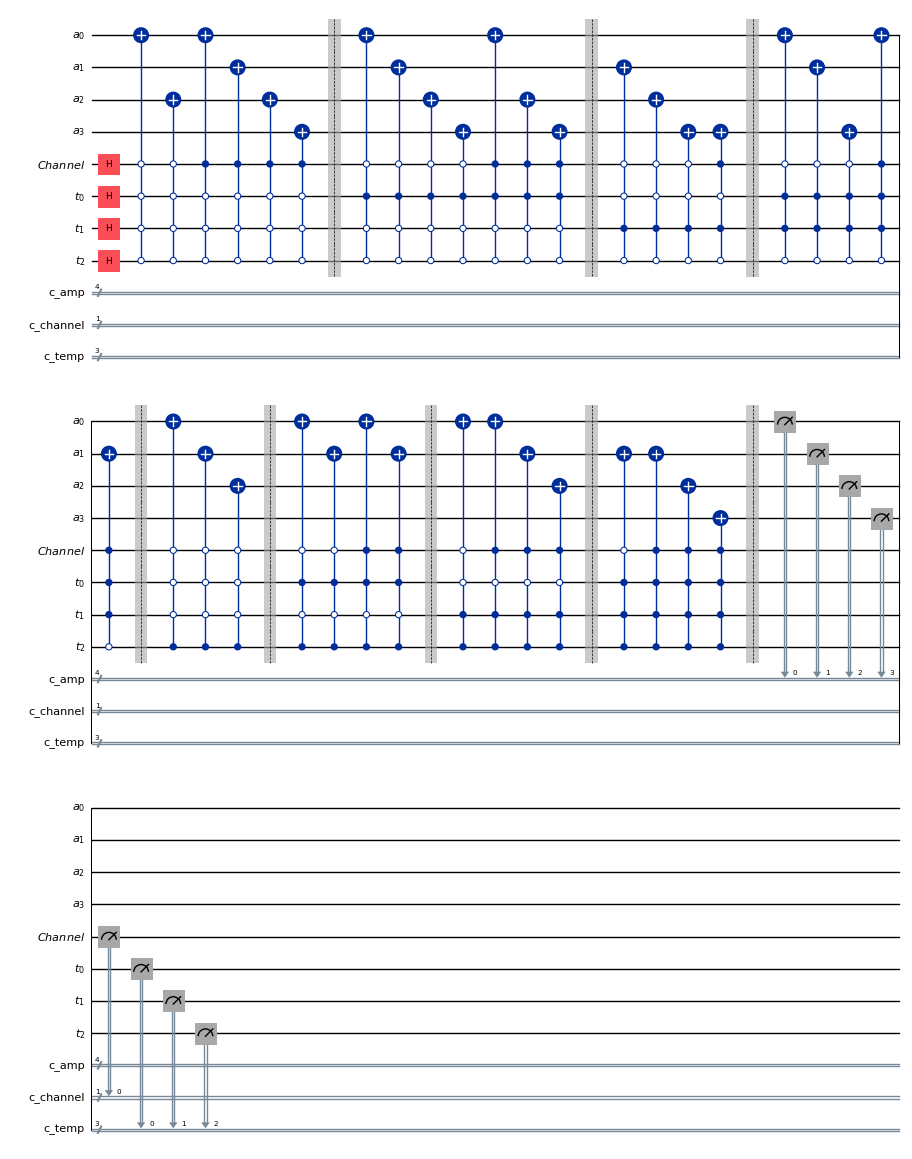

In [5]:
# Quantum register
q_amp = QuantumRegister(AmpQubits, "a")
q_channel = QuantumRegister(ChannelQubits, "Channel")
q_temp = QuantumRegister(TimeQubits, "t")

#classical register
c_amp     = ClassicalRegister(AmpQubits, "c_amp")
c_channel = ClassicalRegister(ChannelQubits, "c_channel")
c_temp    = ClassicalRegister(TimeQubits, "c_temp")

# creation of the circuit with hadamard gates on time qubits
circuit = QuantumCircuit(q_amp, q_channel, q_temp,  c_amp,c_channel, c_temp)
circuit.h(q_temp)
circuit.h(q_channel)


for indexTimeBin, timebinary in enumerate(TimeBin):
    # 1. find null index in the time binary string
    indices_zeros_time = [i+AmpQubits+ChannelQubits for i, bit in enumerate(reversed(timebinary)) if bit == '0']
    # 2. We process the two channels separately within the same time step
    for ch_idx, sig_bin in enumerate([signal_binary1, signal_binary2]):
        
        # We retrieve the bits set to 1 to determine the amplitude of this sample
        # (We move from right to left to correspond to the indices of the qubits)
        indices_ones = [j for j, bit in enumerate(reversed(sig_bin[indexTimeBin])) if bit == '1']
        if indices_ones:
            # Construction of ctrl_state: Channel + Time
            # ch_idx will be ‘0’ for the left and ‘1’ for the right
            ctrl_complet = str(ch_idx) + timebinary
            
            # For each bit with an amplitude of 1, an MCX gate is added
            for amp_bit in indices_ones:
                # The gate is activated only if the register is exactly in the ctrl_complet state
                gate = MCXGate(num_ctrl_qubits=TimeQubits + 1, ctrl_state=ctrl_complet)
                
                # Apply to [Time qubits] + [Channel qubit] -> [Target amplitude qubit]
                circuit.append(gate, list(q_temp) + [q_channel] + [q_amp[amp_bit]])
    circuit.barrier()

circuit.measure(q_amp, c_amp)
circuit.measure(q_channel, c_channel)
circuit.measure(q_temp, c_temp)
display(circuit.draw(output="mpl", scale=0.5))

(CVXPY) Apr 07 11:50:00 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 07 11:50:00 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')


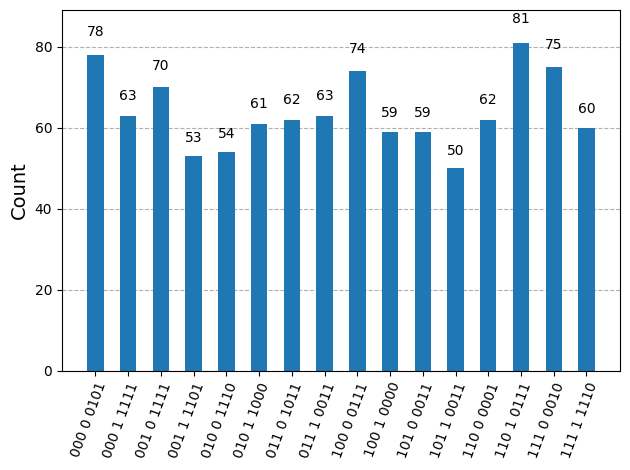

In [6]:
# run on backend then plot the histogramm
simulator = AerSimulator()
stats = simulator.run(circuit.decompose(), shots = 1024).result()
counts = stats.get_counts()
display(plot_histogram(counts))

## Retrieval the signal 
The way to recovert the signal is according the time measured values, the data are rearranged to get the amplitudes value. Then the signal is reconstructed. 
To het a better resolution of the signal in amplitude, the system required more qubit $a$.

In [7]:
# rearranged data by 
data_points = []
for full_bin, count in counts.items():
    # Separation of the amplitudes , channel and time register
    time_bin, channel_bin, amp_bin = full_bin.split(' ')
    
    # Conversion binary -> int
    time_int = int(time_bin, 2)
    channel_int = int(channel_bin, 2)
    amp_int = int(amp_bin, 2)
    
    data_points.append({
        'time': time_int,
        'channel': channel_int,
        'amp': amp_int,
        'probability': count / sum(counts.values())
    })

# Sort by ascending time
data_points.sort(key=lambda x: x['time'])
print(data_points)

# retrieval signals
signal_reconstruit = np.zeros((2, 2**TimeQubits))

for point in data_points:
    t = point['time']
    c = point['channel'] # value is equal to 0 or 1
    a = point['amp']     
    signal_reconstruit[c, t] = a

left = signal_reconstruit[0]
right = signal_reconstruit[1]

[{'time': 0, 'channel': 1, 'amp': 15, 'probability': 0.0615234375}, {'time': 0, 'channel': 0, 'amp': 5, 'probability': 0.076171875}, {'time': 1, 'channel': 0, 'amp': 15, 'probability': 0.068359375}, {'time': 1, 'channel': 1, 'amp': 13, 'probability': 0.0517578125}, {'time': 2, 'channel': 0, 'amp': 14, 'probability': 0.052734375}, {'time': 2, 'channel': 1, 'amp': 8, 'probability': 0.0595703125}, {'time': 3, 'channel': 1, 'amp': 3, 'probability': 0.0615234375}, {'time': 3, 'channel': 0, 'amp': 11, 'probability': 0.060546875}, {'time': 4, 'channel': 1, 'amp': 0, 'probability': 0.0576171875}, {'time': 4, 'channel': 0, 'amp': 7, 'probability': 0.072265625}, {'time': 5, 'channel': 0, 'amp': 3, 'probability': 0.0576171875}, {'time': 5, 'channel': 1, 'amp': 3, 'probability': 0.048828125}, {'time': 6, 'channel': 0, 'amp': 1, 'probability': 0.060546875}, {'time': 6, 'channel': 1, 'amp': 7, 'probability': 0.0791015625}, {'time': 7, 'channel': 0, 'amp': 2, 'probability': 0.0732421875}, {'time': 7,

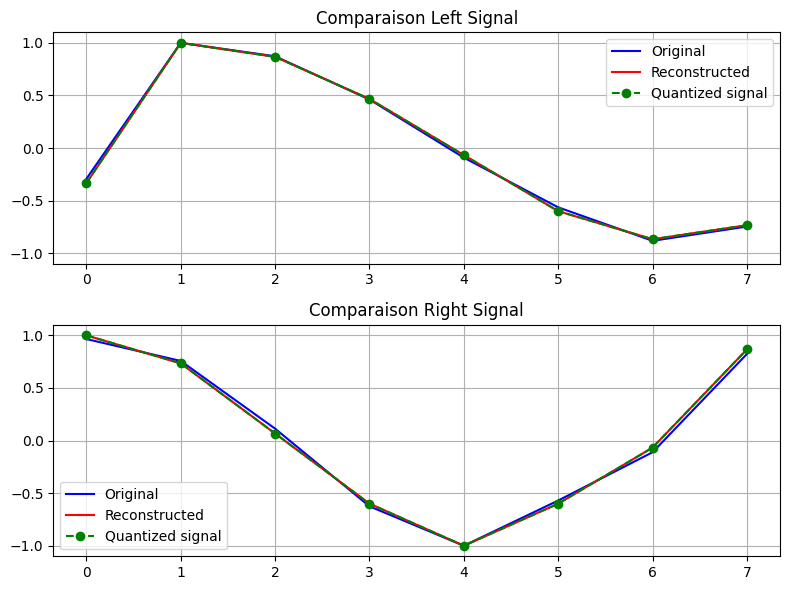

In [8]:
# Plot the retrieval signal with the original and Quantized signal
leftRec = quantize2normalize(left, AmpQubits)
rightRec = quantize2normalize(right, AmpQubits)

# Quantization of the signal 
quantizeSignal_norm1 = quantize2normalize(quantizeSignal1, AmpQubits)
quantizeSignal_norm2 = quantize2normalize(quantizeSignal2, AmpQubits)

fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(signal1, color='blue', label="Original")
axs[0].plot(leftRec, color='red', label="Reconstructed")
axs[0].plot(quantizeSignal_norm1, color='green', marker='o', linestyle='--', label="Quantized signal")
axs[0].set_title("Comparaison Left Signal")
axs[0].set_ylim([-1.1, 1.1])
axs[0].legend()
axs[0].grid(True)

axs[1].plot(signal2, color='blue', label="Original")
axs[1].plot(rightRec, color='red', label="Reconstructed")
axs[1].plot(quantizeSignal_norm2, color='green', marker='o', linestyle='--', label="Quantized signal")
axs[1].set_title("Comparaison Right Signal")
axs[1].grid(True)
axs[1].set_ylim([-1.1, 1.1])
axs[1].legend()
plt.tight_layout()
plt.show()

The reconstructed signal is identical to the quantize signal, because they have the same value in the input of the algorithms. To get a better fidelity of the original signal, the algorithm must have more of qubits to incresae the resolution of the signal. 